"""
Social Media Impact on Teen Mental Health
Analyzing how social media affects stress, anxiety, and sleep

About Dataset
Dataset Overview
This dataset studies how social media use affects the mental health of teenagers. It includes daily habits like social media hours, sleep, stress, anxiety, and physical activity.

The goal is to understand if high social media use is linked with problems like stress, anxiety, and depression. The data helps in analyzing behavior and building machine learning models to predict mental health risk.

Overall, this dataset is useful for basic research and for creating models that can help in early detection of mental health issues in teenagers.

Dataset Tags
mental health, teen health, social media impact, depression prediction, anxiety analysis, machine learning, dataset, behavioral data, health analytics, AI in healthcare

About this file

A dataset of teenagers’ social media habits and mental health factors for basic analysis and ML use.

source: https://www.kaggle.com/datasets/algozee/teenager-menthal-healy/data

https://www.kaggle.com/code/tahafarhan/teen-mental-health-eda#%F0%9F%93%8A-Table-of-Contents
"""

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



In [4]:
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [5]:
# ── Load data ─────────────────────────────────────────────────────────────────
# ── Derived features ──────────────────────────────────────────────────────────
df['mental_health_score']  = (df['stress_level'] + df['anxiety_level'] + df['addiction_level']) / 3
df['age_group']            = pd.cut(df['age'], bins=[12,14,16,19],
                                    labels=['Early Teen\n(13–14)', 'Mid Teen\n(15–16)', 'Late Teen\n(17–19)'])
df['sleep_quality']        = pd.cut(df['sleep_hours'],
                                    bins=[0, 5.5, 7, 9],
                                    labels=['Poor (<5.5h)', 'Fair (5.5–7h)', 'Good (>7h)'])
df['depression_label_str'] = df['depression_label'].map({0: 'No Depression', 1: 'Depression'})
df['social_media_cat']     = pd.cut(df['daily_social_media_hours'],
                                    bins=[0, 2, 5, 8],
                                    labels=['Low (≤2h)', 'Moderate (2–5h)', 'High (>5h)'])

print(f'Dataset shape: {df.shape}')
print(f'Age range: {df.age.min()} – {df.age.max()} years')
print(f'No missing values: {df.isnull().sum().sum() == 0}')
df.head()

Dataset shape: (1200, 18)
Age range: 13 – 19 years
No missing values: True


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,mental_health_score,age_group,sleep_quality,depression_label_str,social_media_cat
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0,1.666667,Early Teen\n(13–14),Good (>7h),No Depression,High (>5h)
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0,6.333333,Late Teen\n(17–19),Good (>7h),No Depression,Low (≤2h)
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0,2.666667,Late Teen\n(17–19),Good (>7h),No Depression,Low (≤2h)
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0,5.666667,Mid Teen\n(15–16),Fair (5.5–7h),No Depression,High (>5h)
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0,3.333333,Mid Teen\n(15–16),Poor (<5.5h),No Depression,Moderate (2–5h)


In [6]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label',
       'mental_health_score', 'age_group', 'sleep_quality',
       'depression_label_str', 'social_media_cat'],
      dtype='str')

In [7]:
print("\n=== DESCRIPTIVE STATISTICS ===")
print(df.describe())


=== DESCRIPTIVE STATISTICS ===
               age  daily_social_media_hours  sleep_hours  \
count  1200.000000               1200.000000  1200.000000   
mean     15.928333                  4.536667     6.449417   
std       2.021947                  2.029599     1.442677   
min      13.000000                  1.000000     4.000000   
25%      14.000000                  2.800000     5.200000   
50%      16.000000                  4.500000     6.500000   
75%      18.000000                  6.300000     7.600000   
max      19.000000                  8.000000     9.000000   

       screen_time_before_sleep  academic_performance  physical_activity  \
count               1200.000000           1200.000000        1200.000000   
mean                   1.740333              2.990383           1.014500   
std                    0.716660              0.576758           0.582185   
min                    0.500000              2.000000           0.000000   
25%                    1.100000       

In [8]:
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())


=== MISSING VALUES ===
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
mental_health_score         0
age_group                   0
sleep_quality               0
depression_label_str        0
social_media_cat            0
dtype: int64


In [9]:
df.dtypes

age                            int64
gender                           str
daily_social_media_hours     float64
platform_usage                   str
sleep_hours                  float64
screen_time_before_sleep     float64
academic_performance         float64
physical_activity            float64
social_interaction_level         str
stress_level                   int64
anxiety_level                  int64
addiction_level                int64
depression_label               int64
mental_health_score          float64
age_group                   category
sleep_quality               category
depression_label_str             str
social_media_cat            category
dtype: object

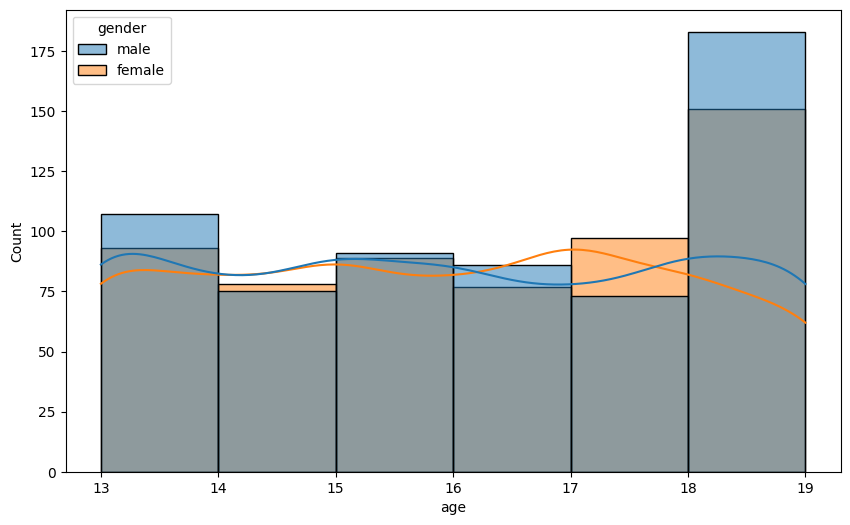

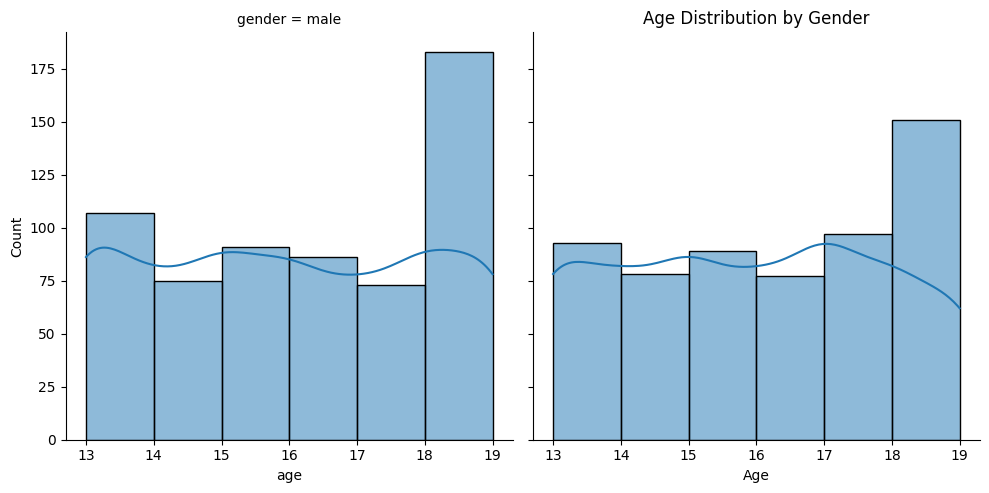

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='age',
    hue='gender',
    bins=6,
    kde=True
)
sns.displot(
    data=df,
    x='age',
    col='gender',
    bins=6,
    kde=True
)

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution by Gender')

plt.show()

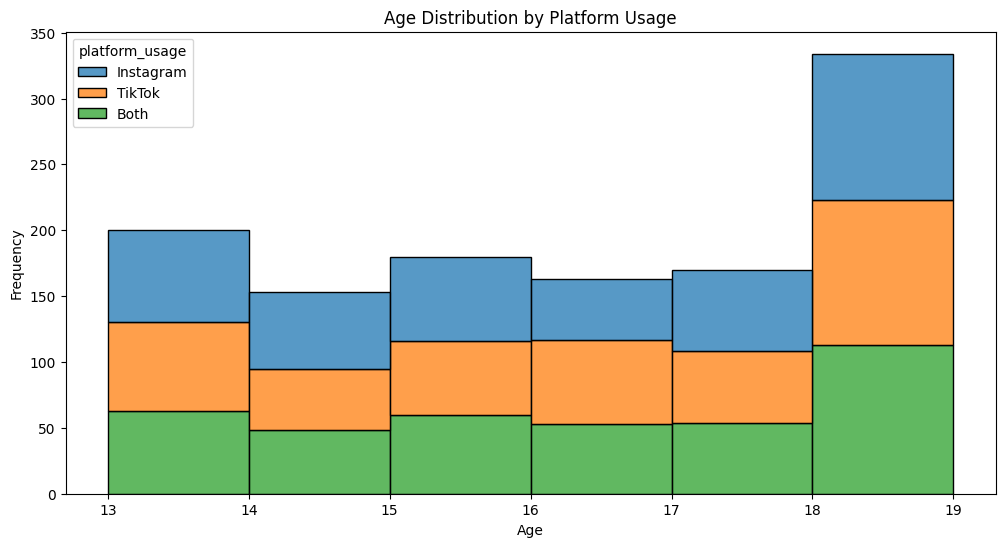

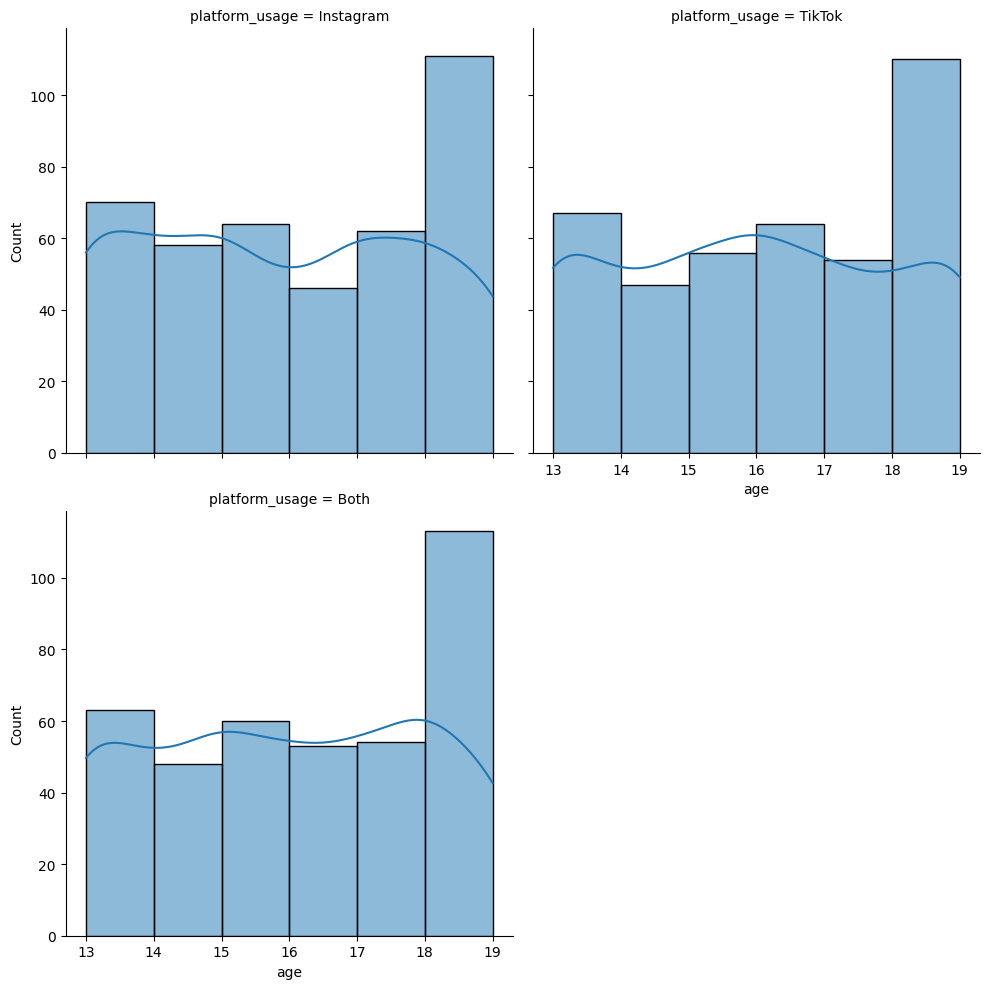

In [11]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='age',
    hue='platform_usage',
    bins=6,
    multiple='stack'
)

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution by Platform Usage')

plt.show()

sns.displot(
    data=df,
    x='age',
    col='platform_usage',
    bins=6,
    kde=True,
    col_wrap=2
)

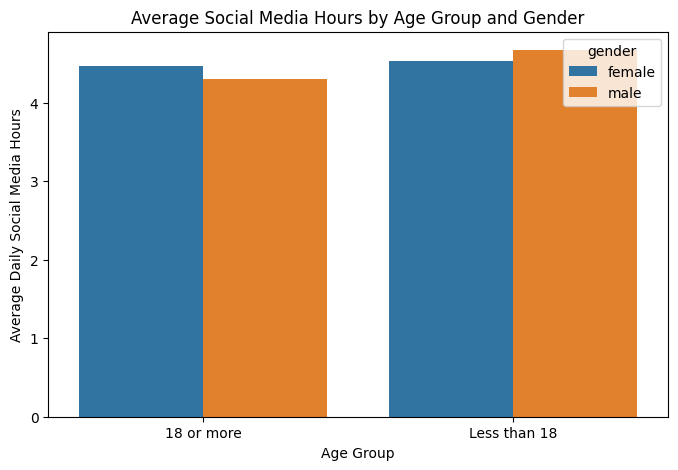

In [12]:
# Criar grupos de idade
df['age_group'] = df['age'].apply(
    lambda x: 'Less than 18' if x < 18 else '18 or more'
)

# Média de horas por grupo e gênero
avg_hours = df.groupby(
    ['age_group', 'gender']
)['daily_social_media_hours'].mean().reset_index()

# Plot
plt.figure(figsize=(8,5))

sns.barplot(
    data=avg_hours,
    x='age_group',
    y='daily_social_media_hours',
    hue='gender'
)

plt.xlabel('Age Group')
plt.ylabel('Average Daily Social Media Hours')
plt.title('Average Social Media Hours by Age Group and Gender')

plt.show()

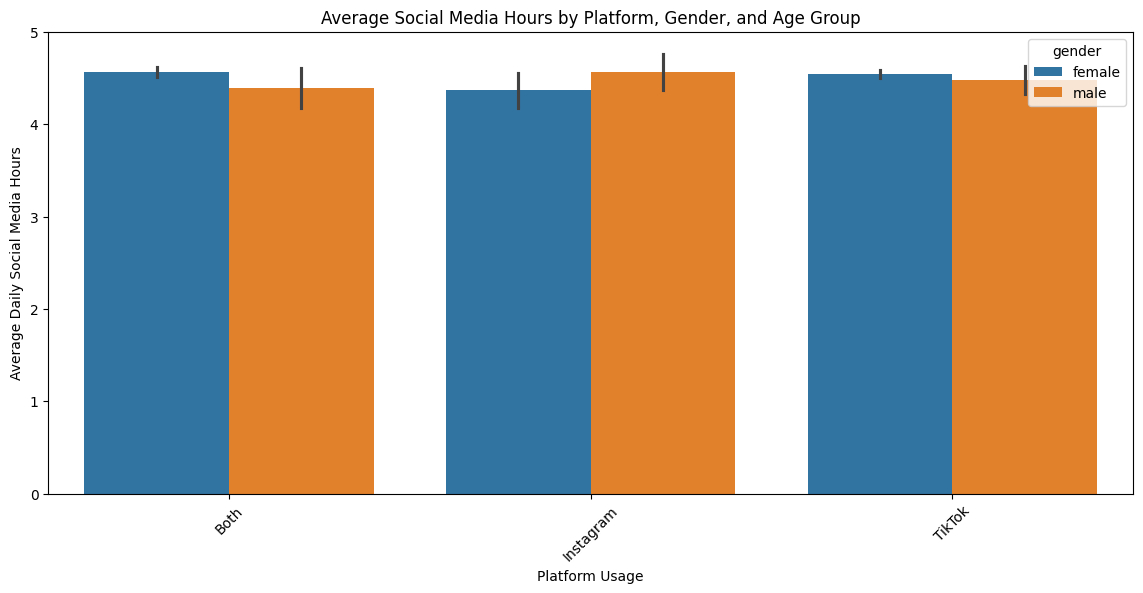

In [13]:
# Criar grupos de idade
df['age_group'] = df['age'].apply(
    lambda x: 'Less than 18' if x < 18 else '18 or more'
)

# Média por grupo, gênero e plataforma
avg_hours = df.groupby(
    ['age_group', 'gender', 'platform_usage']
)['daily_social_media_hours'].mean().reset_index()

# Plot
plt.figure(figsize=(14,6))

sns.barplot(
    data=avg_hours,
    x='platform_usage',
    y='daily_social_media_hours',
    hue='gender'
)

plt.xlabel('Platform Usage')
plt.ylabel('Average Daily Social Media Hours')
plt.title('Average Social Media Hours by Platform, Gender, and Age Group')

plt.xticks(rotation=45)

plt.show()

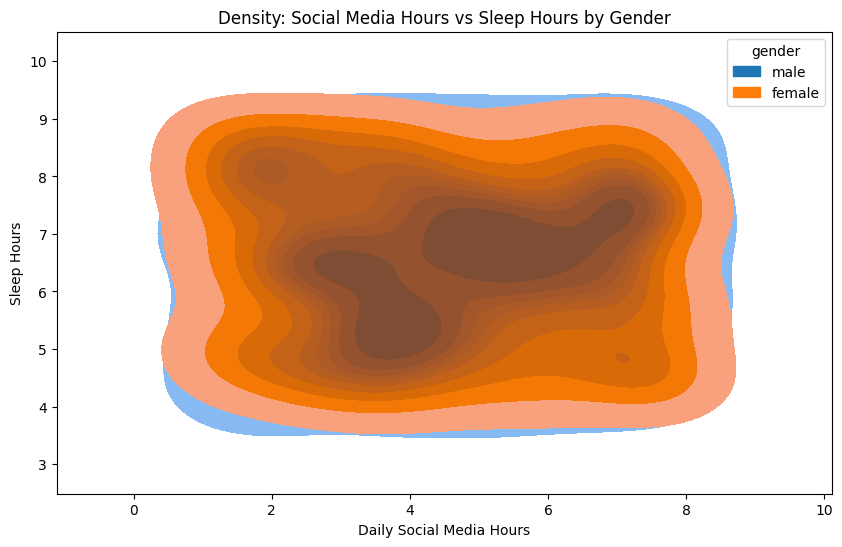

In [14]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x='daily_social_media_hours',
    y='sleep_hours',
    hue='gender',
    fill=True
)

plt.xlabel('Daily Social Media Hours')
plt.ylabel('Sleep Hours')
plt.title('Density: Social Media Hours vs Sleep Hours by Gender')

plt.show()

<Axes: xlabel='stress_level', ylabel='sleep_hours'>

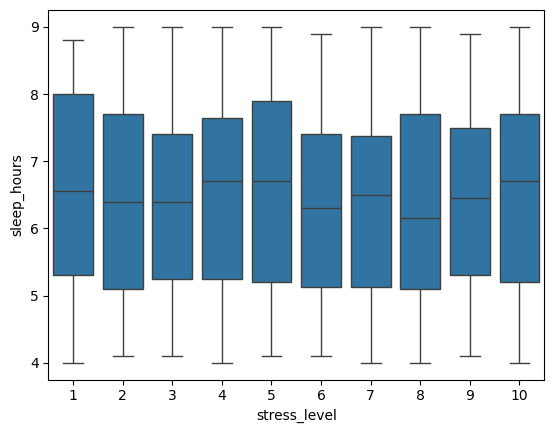

In [15]:
sns.boxplot(
    data=df,
    x='stress_level',
    y='sleep_hours'
)

([0, 1, 2],
 [Text(0, 0, 'Instagram'), Text(1, 0, 'TikTok'), Text(2, 0, 'Both')])

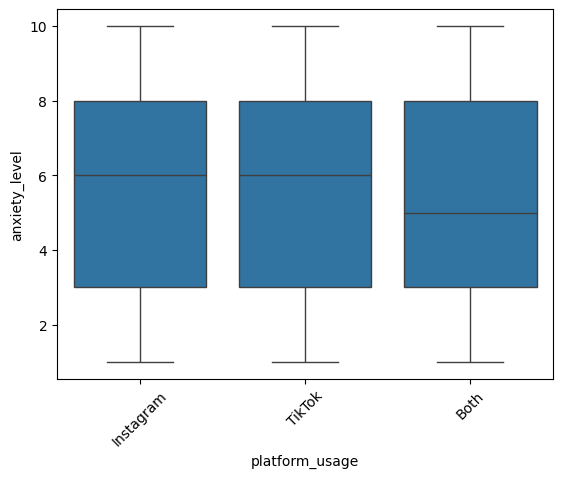

In [16]:
sns.boxplot(
    data=df,
    x='platform_usage',
    y='anxiety_level'
)

plt.xticks(rotation=45)

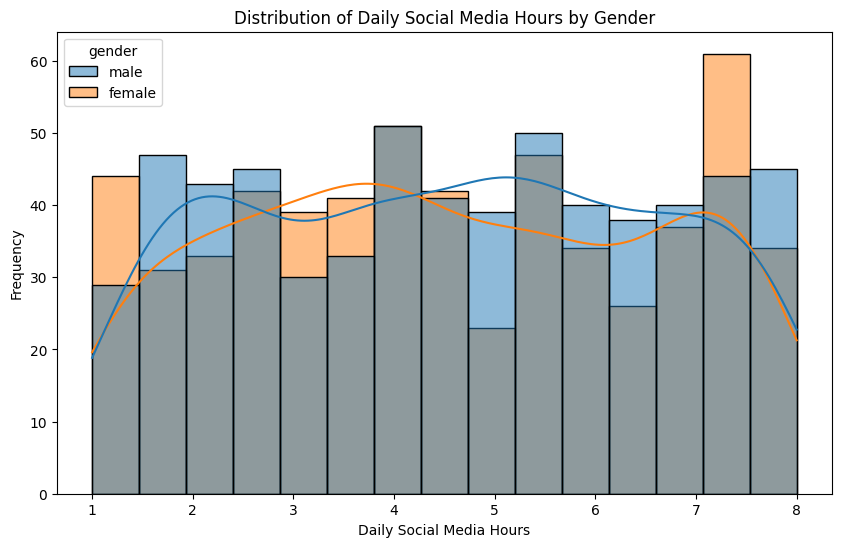

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='daily_social_media_hours',
    hue='gender',
    multiple='layer',
    kde=True,
    bins=15
)

plt.xlabel('Daily Social Media Hours')
plt.ylabel('Frequency')
plt.title('Distribution of Daily Social Media Hours by Gender')

plt.show()

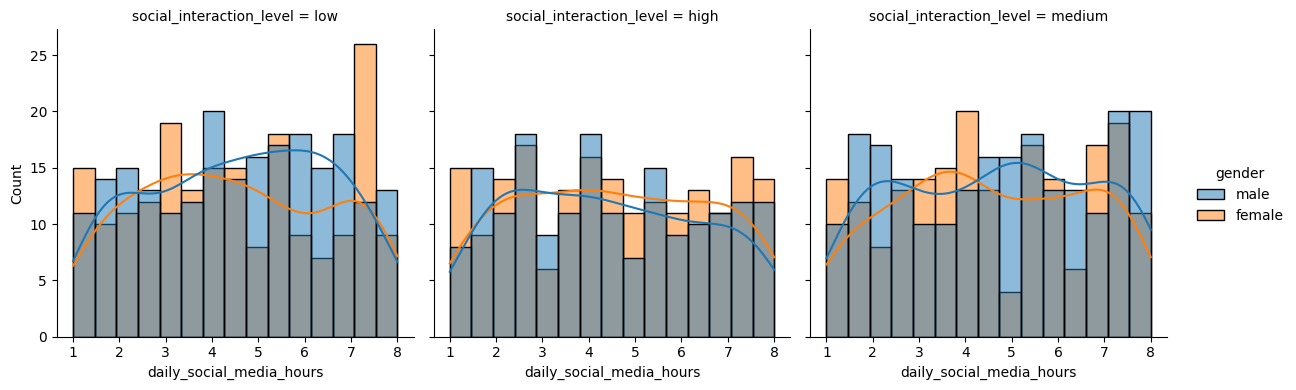

In [18]:
sns.displot(
    data=df,
    x='daily_social_media_hours',
    hue='gender',
    col='social_interaction_level',
    bins=15,
    kde=True,
    multiple='layer',
    col_wrap=3,
    height=4
)

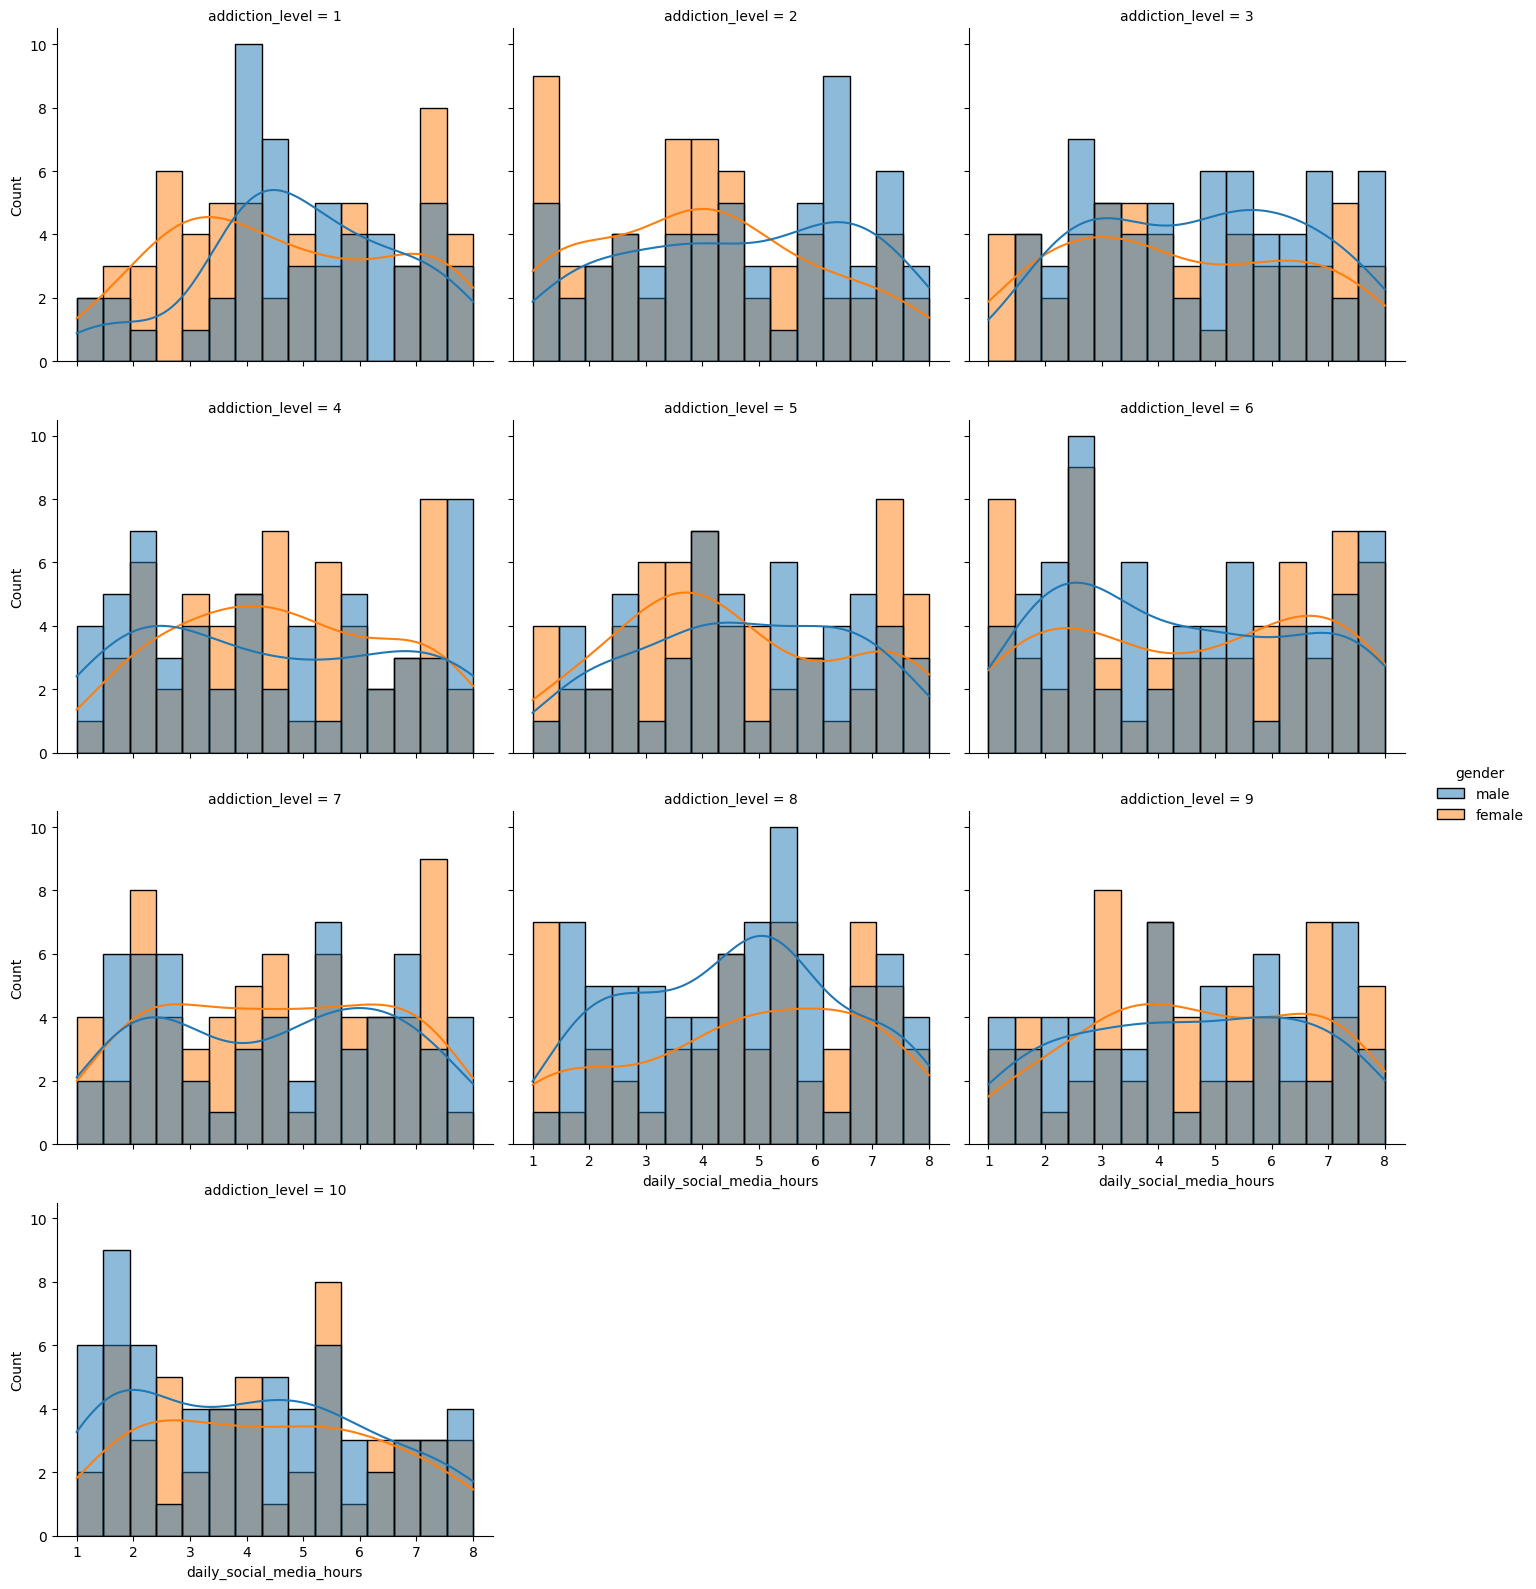

In [19]:
sns.displot(
    data=df,
    x='daily_social_media_hours',
    hue='gender',
    col='addiction_level',
    bins=15,
    kde=True,
    multiple='layer',
    col_wrap=3,
    height=4,
    aspect=1.2
)

plt.show()

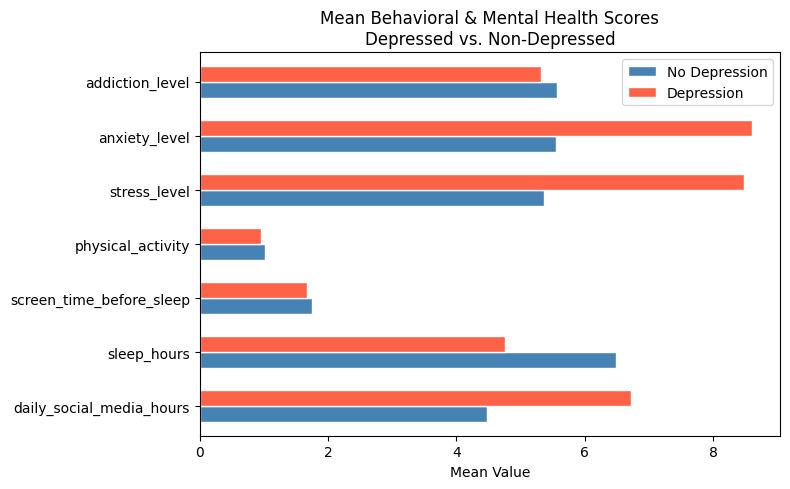

                          No Depression  Depression
daily_social_media_hours           4.48        6.72
sleep_hours                        6.49        4.76
screen_time_before_sleep           1.74        1.67
physical_activity                  1.02        0.95
stress_level                       5.37        8.48
anxiety_level                      5.56        8.61
addiction_level                    5.57        5.32


In [20]:
profile_cols = ['daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
                'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level']

profile = df.groupby('depression_label')[profile_cols].mean().T
profile.columns = ['No Depression', 'Depression']

profile.plot(kind='barh', figsize=(8, 5), color=['steelblue', 'tomato'],
             edgecolor='white', width=0.6)
plt.title('Mean Behavioral & Mental Health Scores\nDepressed vs. Non-Depressed')
plt.xlabel('Mean Value')
plt.legend()
plt.tight_layout()
plt.show()

print(profile.round(2))

In [21]:
!pip install scikit-learn

In [22]:
!pip install imbalanced-learn

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [24]:
df_model = df.copy()

# Encode categoricals
le = LabelEncoder()
for col in ['gender', 'platform_usage', 'social_interaction_level']:
    df_model[col] = le.fit_transform(df_model[col])

# Composite mental health score
df_model['mental_health_score'] = (df_model['stress_level'] +
                                    df_model['anxiety_level'] +
                                    df_model['addiction_level']) / 3

feature_cols = ['age', 'gender', 'daily_social_media_hours', 'platform_usage',
                'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
                'physical_activity', 'social_interaction_level',
                'stress_level', 'anxiety_level', 'addiction_level', 'mental_health_score']

X = df_model[feature_cols]
y = df_model['depression_label']

print(f"Features: {X.shape[1]} | Samples: {X.shape[0]}")

Features: 13 | Samples: 1200


In [25]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Before SMOTE: {dict(pd.Series(y).value_counts())}")
print(f"After SMOTE:  {dict(pd.Series(y_resampled).value_counts())}")

Before SMOTE: {0: np.int64(1169), 1: np.int64(31)}
After SMOTE:  {0: np.int64(1169), 1: np.int64(1169)}


In [26]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             random_state=42, n_jobs=-1)

# Stratified cross-validation on original (imbalanced) data to get real-world AUC
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')

print(f"Cross-validated ROC-AUC: {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")

# Fit on SMOTE data for feature importance
rf.fit(X_resampled, y_resampled)

Cross-validated ROC-AUC: 0.999 ± 0.002


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

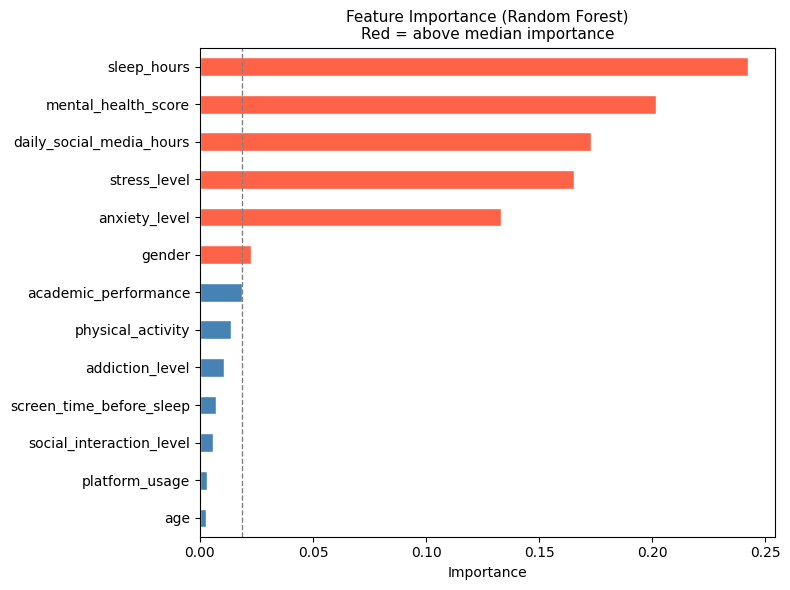


Top 5 predictors of depression risk:
sleep_hours                 0.2421
mental_health_score         0.2015
daily_social_media_hours    0.1729
stress_level                0.1656
anxiety_level               0.1331
dtype: float64


In [27]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

colors = ['tomato' if imp > importances.median() else 'steelblue' for imp in importances]

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance (Random Forest)\nRed = above median importance', fontsize=11)
ax.set_xlabel('Importance')
ax.axvline(importances.median(), color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

print("\nTop 5 predictors of depression risk:")
print(importances.sort_values(ascending=False).head(5).round(4))

In [28]:
# ── Plot styling ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Color palettes ────────────────────────────────────────────────────────────
PAL_MAIN    = sns.color_palette('Set2')
PAL_MENTAL  = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']   # stress gradient
PAL_GENDER  = {'male': '#3498db', 'female': '#e91e8c'}
PAL_PLAT    = {'Instagram': '#C13584', 'TikTok': '#010101', 'Both': '#69C9D0'}
PAL_DEP     = {0: '#2ecc71', 1: '#e74c3c'}

print('✅ Libraries loaded!')

✅ Libraries loaded!


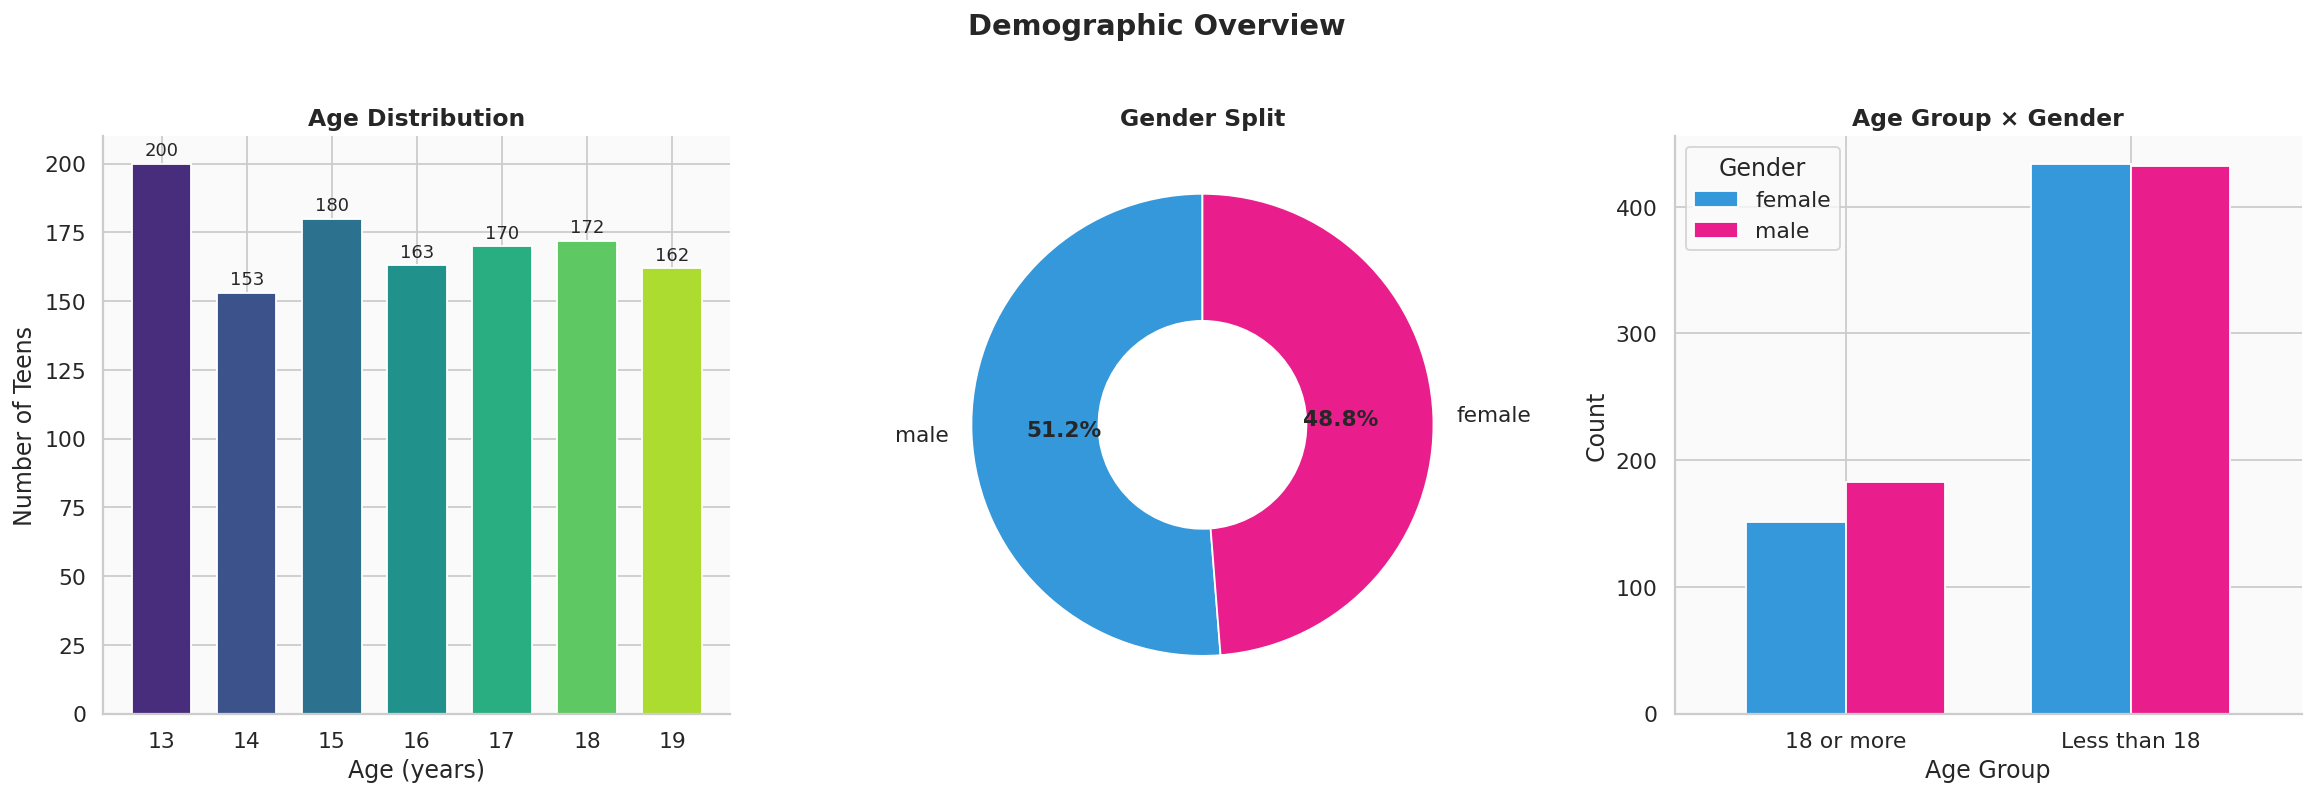

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Age distribution ──────────────────────────────────────────────────────────
age_counts = df['age'].value_counts().sort_index()
axes[0].bar(age_counts.index, age_counts.values,
            color=sns.color_palette('viridis', len(age_counts)), edgecolor='white', width=0.7)
axes[0].set_title('Age Distribution', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Number of Teens')
for x, y in zip(age_counts.index, age_counts.values):
    axes[0].text(x, y + 3, str(y), ha='center', fontsize=10)

# ── Gender donut chart ────────────────────────────────────────────────────────
gender_counts = df['gender'].value_counts()
colors_g = [PAL_GENDER[g] for g in gender_counts.index]
wedges, texts, autotexts = axes[1].pie(
    gender_counts.values, labels=gender_counts.index,
    autopct='%1.1f%%', colors=colors_g,
    wedgeprops={'width': 0.55}, startangle=90,
    textprops={'fontsize': 12})
for at in autotexts: at.set_fontweight('bold')
axes[1].set_title('Gender Split', fontweight='bold', fontsize=13)

# ── Age group × Gender grouped bar ───────────────────────────────────────────
ag_gender = df.groupby(['age_group', 'gender'], observed=True).size().unstack()
ag_gender.plot(kind='bar', ax=axes[2], color=[PAL_GENDER['male'], PAL_GENDER['female']],
               edgecolor='white', width=0.7)
axes[2].set_title('Age Group × Gender', fontweight='bold', fontsize=13)
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Gender')

plt.suptitle('Demographic Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

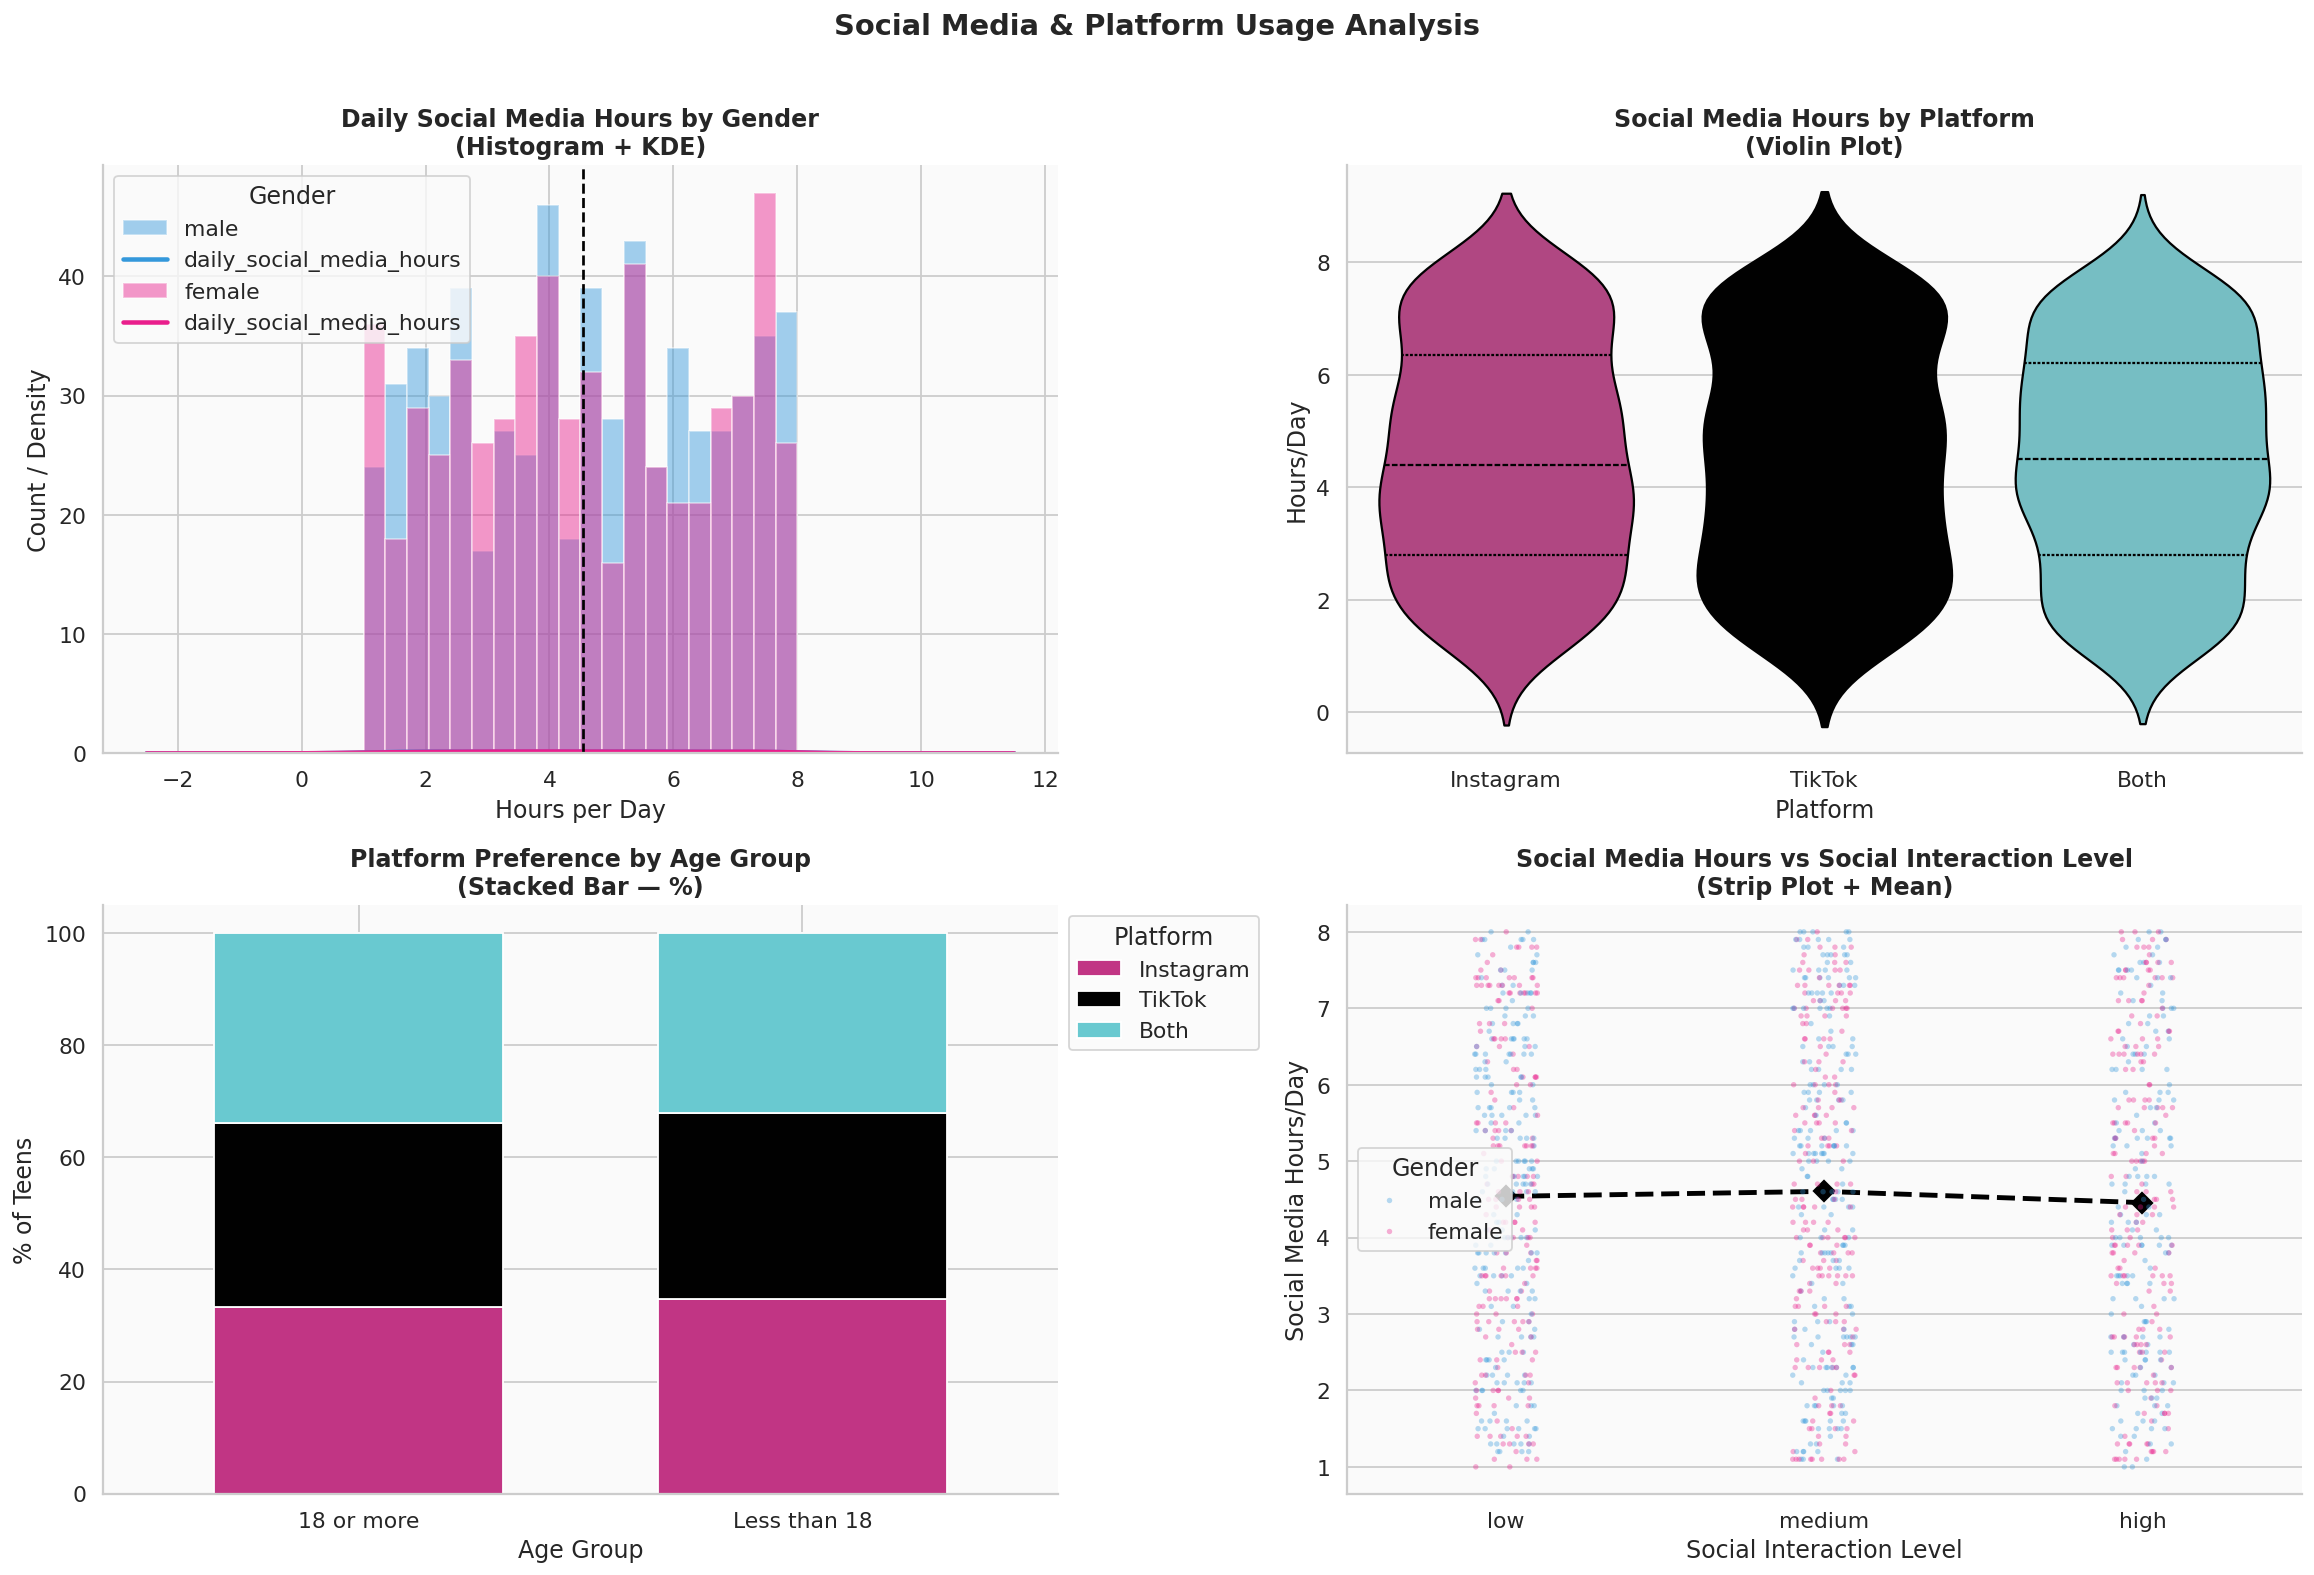

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── Histogram + KDE: Daily social media hours ─────────────────────────────────
for gender, color in PAL_GENDER.items():
    subset = df[df['gender'] == gender]['daily_social_media_hours']
    axes[0,0].hist(subset, bins=20, alpha=0.45, color=color, label=gender, edgecolor='white')
    subset.plot.kde(ax=axes[0,0], color=color, lw=2.5)
axes[0,0].set_title('Daily Social Media Hours by Gender\n(Histogram + KDE)', fontweight='bold')
axes[0,0].set_xlabel('Hours per Day')
axes[0,0].set_ylabel('Count / Density')
axes[0,0].legend(title='Gender')
axes[0,0].axvline(df['daily_social_media_hours'].mean(), color='black',
                   lw=1.5, linestyle='--', label=f"Mean={df['daily_social_media_hours'].mean():.1f}h")

# ── Violin plot: Social media hours by platform ───────────────────────────────
platform_order = ['Instagram', 'TikTok', 'Both']
sns.violinplot(data=df, x='platform_usage', y='daily_social_media_hours',
               order=platform_order, palette=PAL_PLAT,
               inner='quartile', ax=axes[0,1])
axes[0,1].set_title('Social Media Hours by Platform\n(Violin Plot)', fontweight='bold')
axes[0,1].set_xlabel('Platform')
axes[0,1].set_ylabel('Hours/Day')

# ── Stacked bar: Platform usage by age group ──────────────────────────────────
plat_age = df.groupby(['age_group', 'platform_usage'], observed=True).size().unstack(fill_value=0)
plat_age_pct = plat_age.div(plat_age.sum(axis=1), axis=0) * 100
plat_age_pct[['Instagram','TikTok','Both']].plot(
    kind='bar', stacked=True, ax=axes[1,0],
    color=[PAL_PLAT['Instagram'], PAL_PLAT['TikTok'], PAL_PLAT['Both']],
    edgecolor='white', width=0.65)
axes[1,0].set_title('Platform Preference by Age Group\n(Stacked Bar — %)', fontweight='bold')
axes[1,0].set_ylabel('% of Teens')
axes[1,0].set_xlabel('Age Group')
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].legend(title='Platform', bbox_to_anchor=(1, 1))

# ── Strip plot: Social media hours by social interaction level ────────────────
order_sil = ['low', 'medium', 'high']
sns.stripplot(data=df, x='social_interaction_level', y='daily_social_media_hours',
              order=order_sil, hue='gender', palette=PAL_GENDER,
              alpha=0.35, jitter=True, ax=axes[1,1], size=3)
sns.pointplot(data=df, x='social_interaction_level', y='daily_social_media_hours',
              order=order_sil, color='black', markers='D',
              linestyles='--', ax=axes[1,1], errorbar=None)
axes[1,1].set_title('Social Media Hours vs Social Interaction Level\n(Strip Plot + Mean)', fontweight='bold')
axes[1,1].set_xlabel('Social Interaction Level')
axes[1,1].set_ylabel('Social Media Hours/Day')
axes[1,1].legend(title='Gender')

plt.suptitle('Social Media & Platform Usage Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

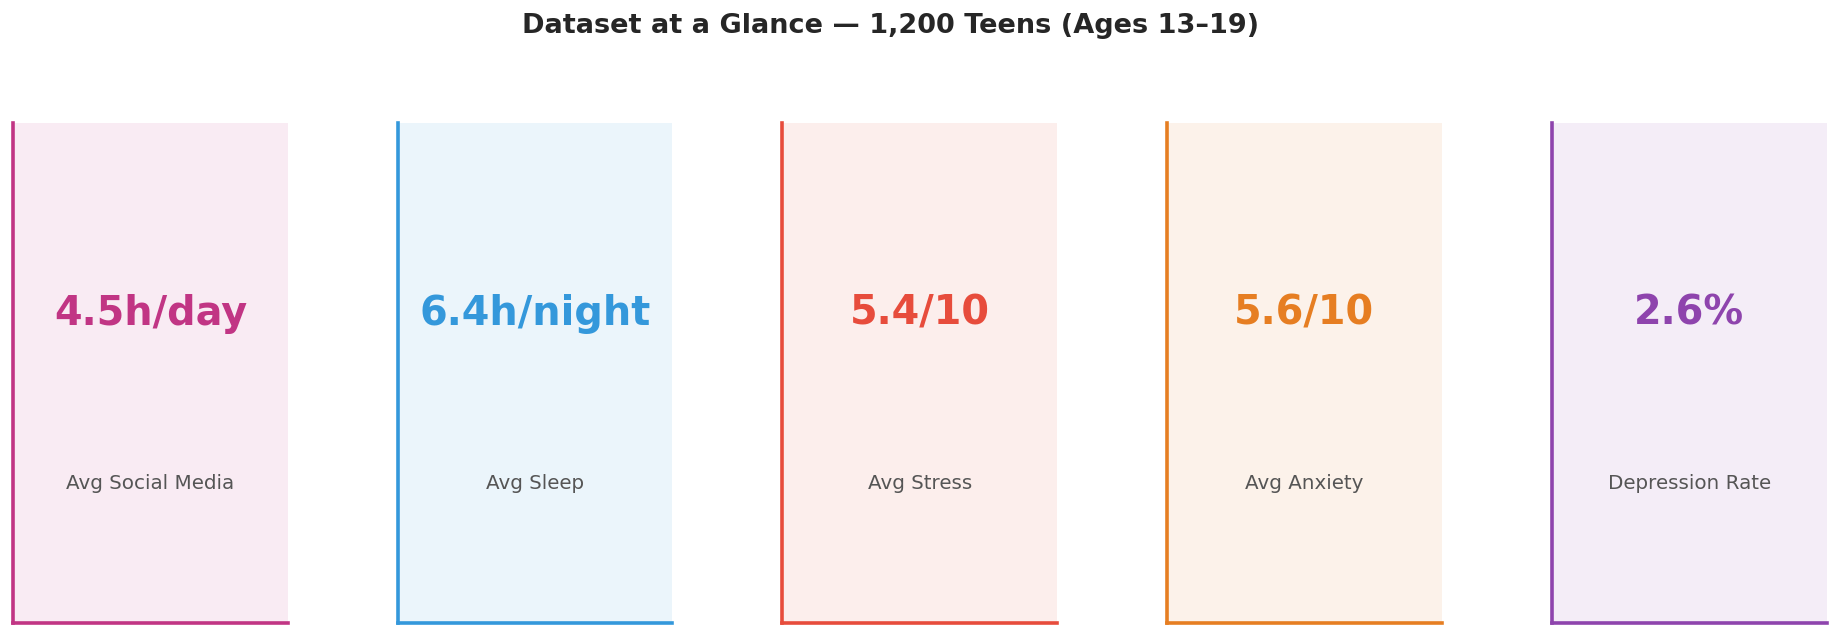

In [31]:
# ── Quick snapshot dashboard ──────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 5, figure=fig, wspace=0.4)

metrics = [
    ('Avg Social Media', f"{df['daily_social_media_hours'].mean():.1f}h/day", '#C13584'),
    ('Avg Sleep',        f"{df['sleep_hours'].mean():.1f}h/night",            '#3498db'),
    ('Avg Stress',       f"{df['stress_level'].mean():.1f}/10",               '#e74c3c'),
    ('Avg Anxiety',      f"{df['anxiety_level'].mean():.1f}/10",              '#e67e22'),
    ('Depression Rate',  f"{df['depression_label'].mean()*100:.1f}%",         '#8e44ad'),
]

for i, (label, val, color) in enumerate(metrics):
    ax = fig.add_subplot(gs[i])
    ax.set_facecolor(color + '18')
    ax.text(0.5, 0.62, val, ha='center', va='center', fontsize=22,
            fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.28, label, ha='center', va='center', fontsize=11,
            color='#555', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(2)

fig.suptitle('Dataset at a Glance — 1,200 Teens (Ages 13–19)', fontsize=15, fontweight='bold', y=1.05)
plt.show()

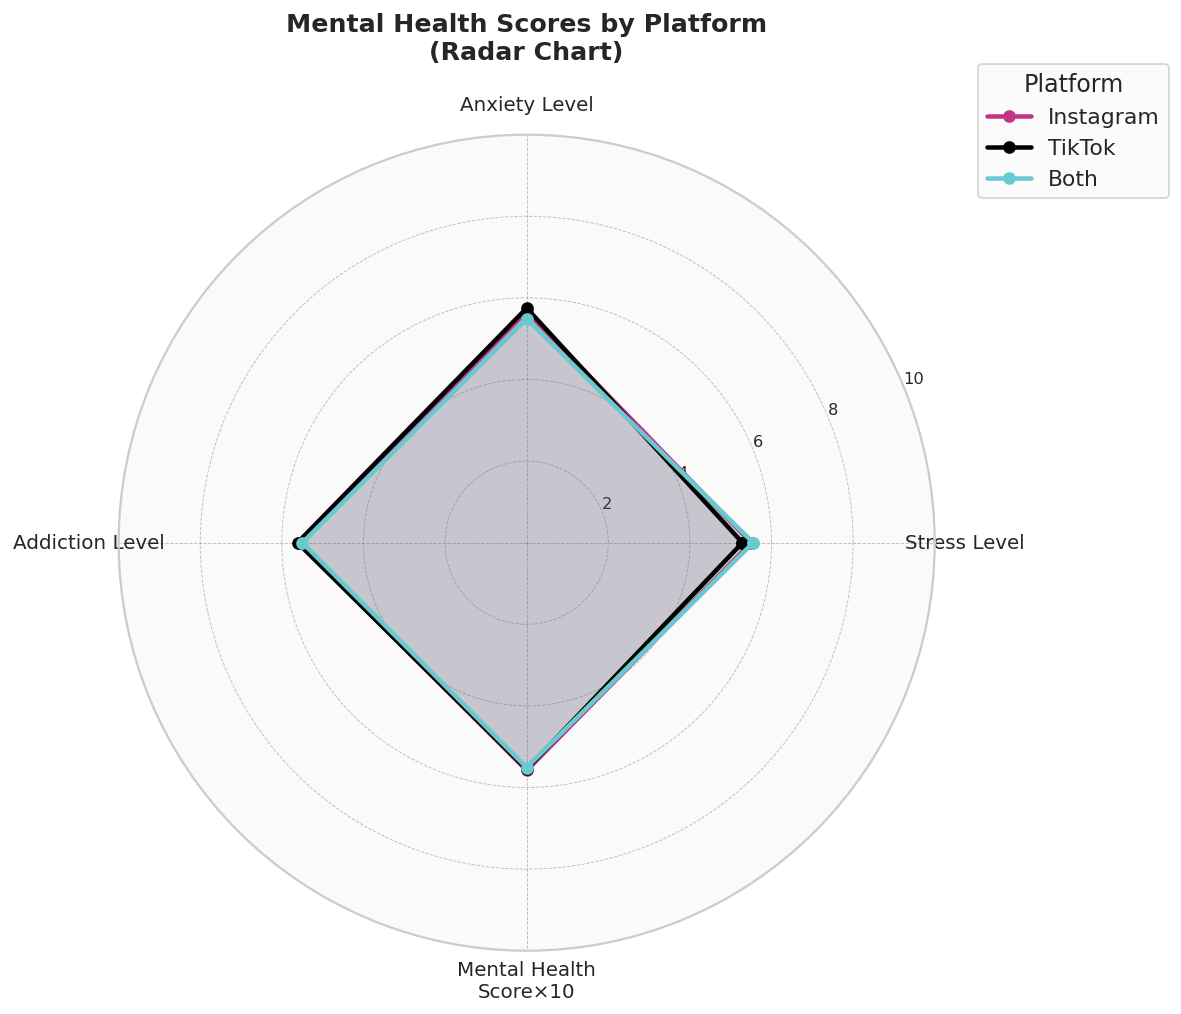

In [32]:
# ── Radar chart: Avg mental health scores by platform ────────────────────────
from matplotlib.patches import FancyArrowPatch

categories = ['Stress Level', 'Anxiety Level', 'Addiction Level', 'Mental Health\nScore×10']
platforms  = ['Instagram', 'TikTok', 'Both']
colors_rad = [PAL_PLAT['Instagram'], PAL_PLAT['TikTok'], PAL_PLAT['Both']]

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))

angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

for plat, color in zip(platforms, colors_rad):
    sub = df[df['platform_usage'] == plat]
    vals = [
        sub['stress_level'].mean(),
        sub['anxiety_level'].mean(),
        sub['addiction_level'].mean(),
        sub['mental_health_score'].mean() * 10 / 10
    ]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', lw=2.5, color=color, label=plat)
    ax.fill(angles, vals, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(['2','4','6','8','10'], size=9)
ax.set_title('Mental Health Scores by Platform\n(Radar Chart)', fontweight='bold', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), title='Platform')
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

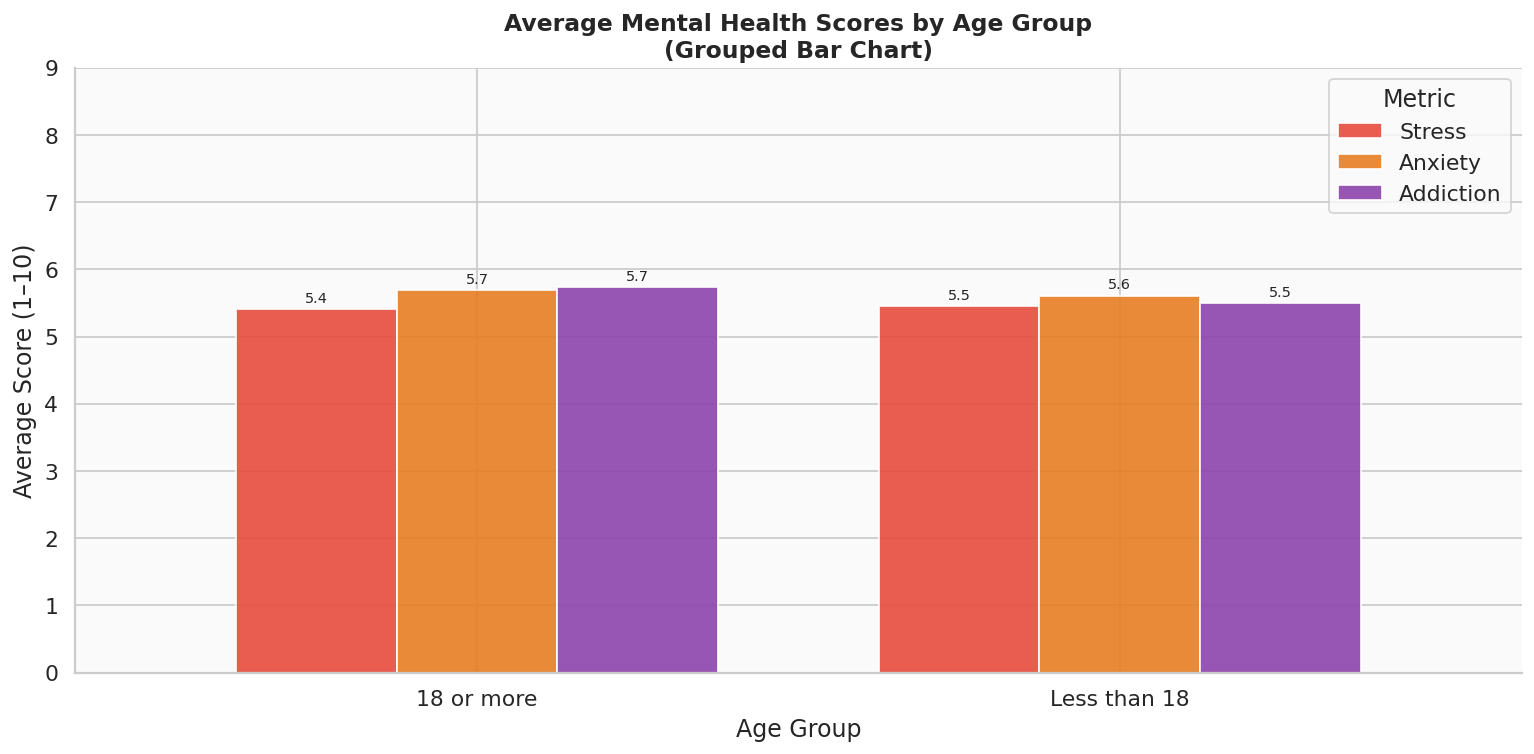

In [33]:
# ── Grouped bar: Mean mental health scores by age group ───────────────────────
age_mental = df.groupby('age_group', observed=True)[['stress_level','anxiety_level','addiction_level']].mean()

fig, ax = plt.subplots(figsize=(12, 6))
age_mental.plot(kind='bar', ax=ax,
                color=['#e74c3c', '#e67e22', '#8e44ad'],
                edgecolor='white', width=0.75, alpha=0.9)
ax.set_title('Average Mental Health Scores by Age Group\n(Grouped Bar Chart)', fontweight='bold', fontsize=13)
ax.set_xlabel('Age Group')
ax.set_ylabel('Average Score (1–10)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Metric', labels=['Stress', 'Anxiety', 'Addiction'])
ax.set_ylim(0, 9)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

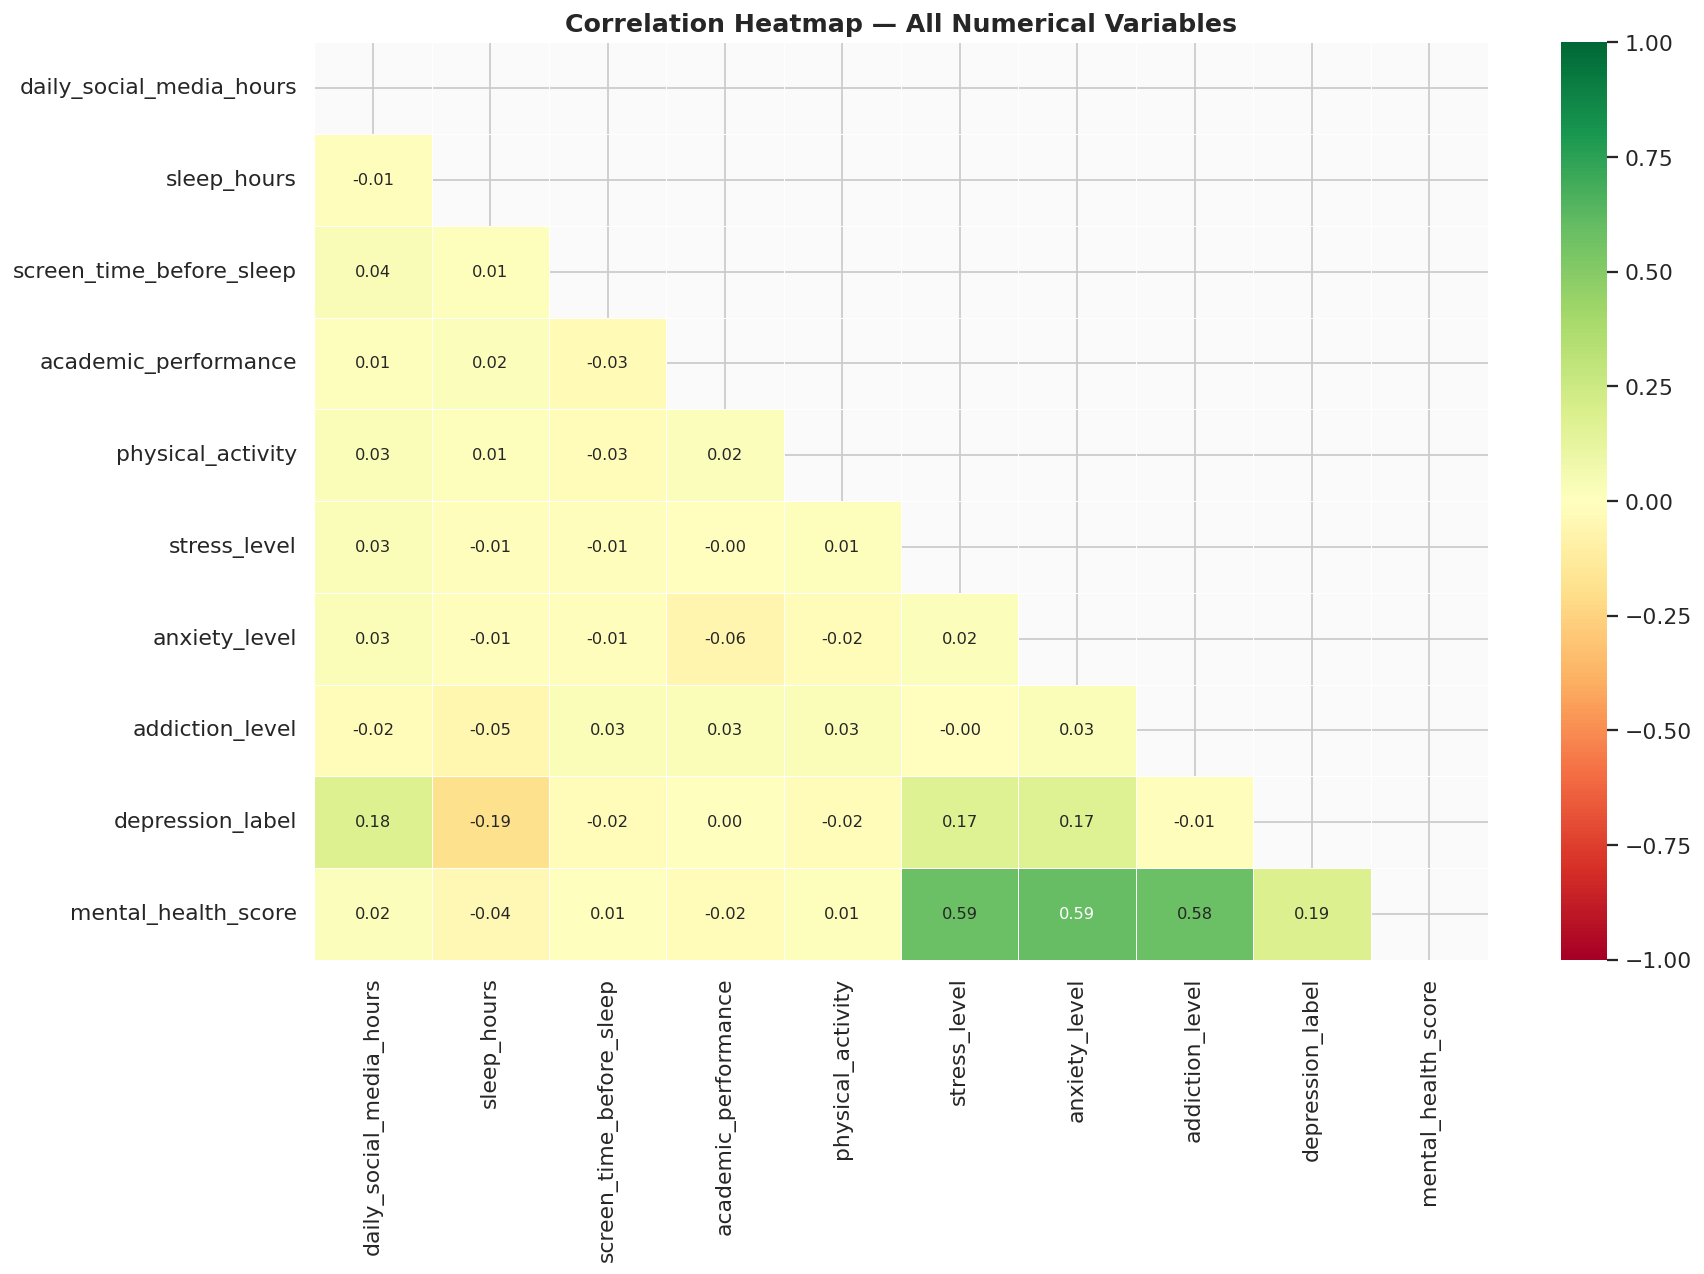

In [34]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
num_cols = ['daily_social_media_hours','sleep_hours','screen_time_before_sleep',
            'academic_performance','physical_activity','stress_level',
            'anxiety_level','addiction_level','depression_label','mental_health_score']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, center=0,
            annot_kws={'size': 9})
ax.set_title('Correlation Heatmap — All Numerical Variables',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

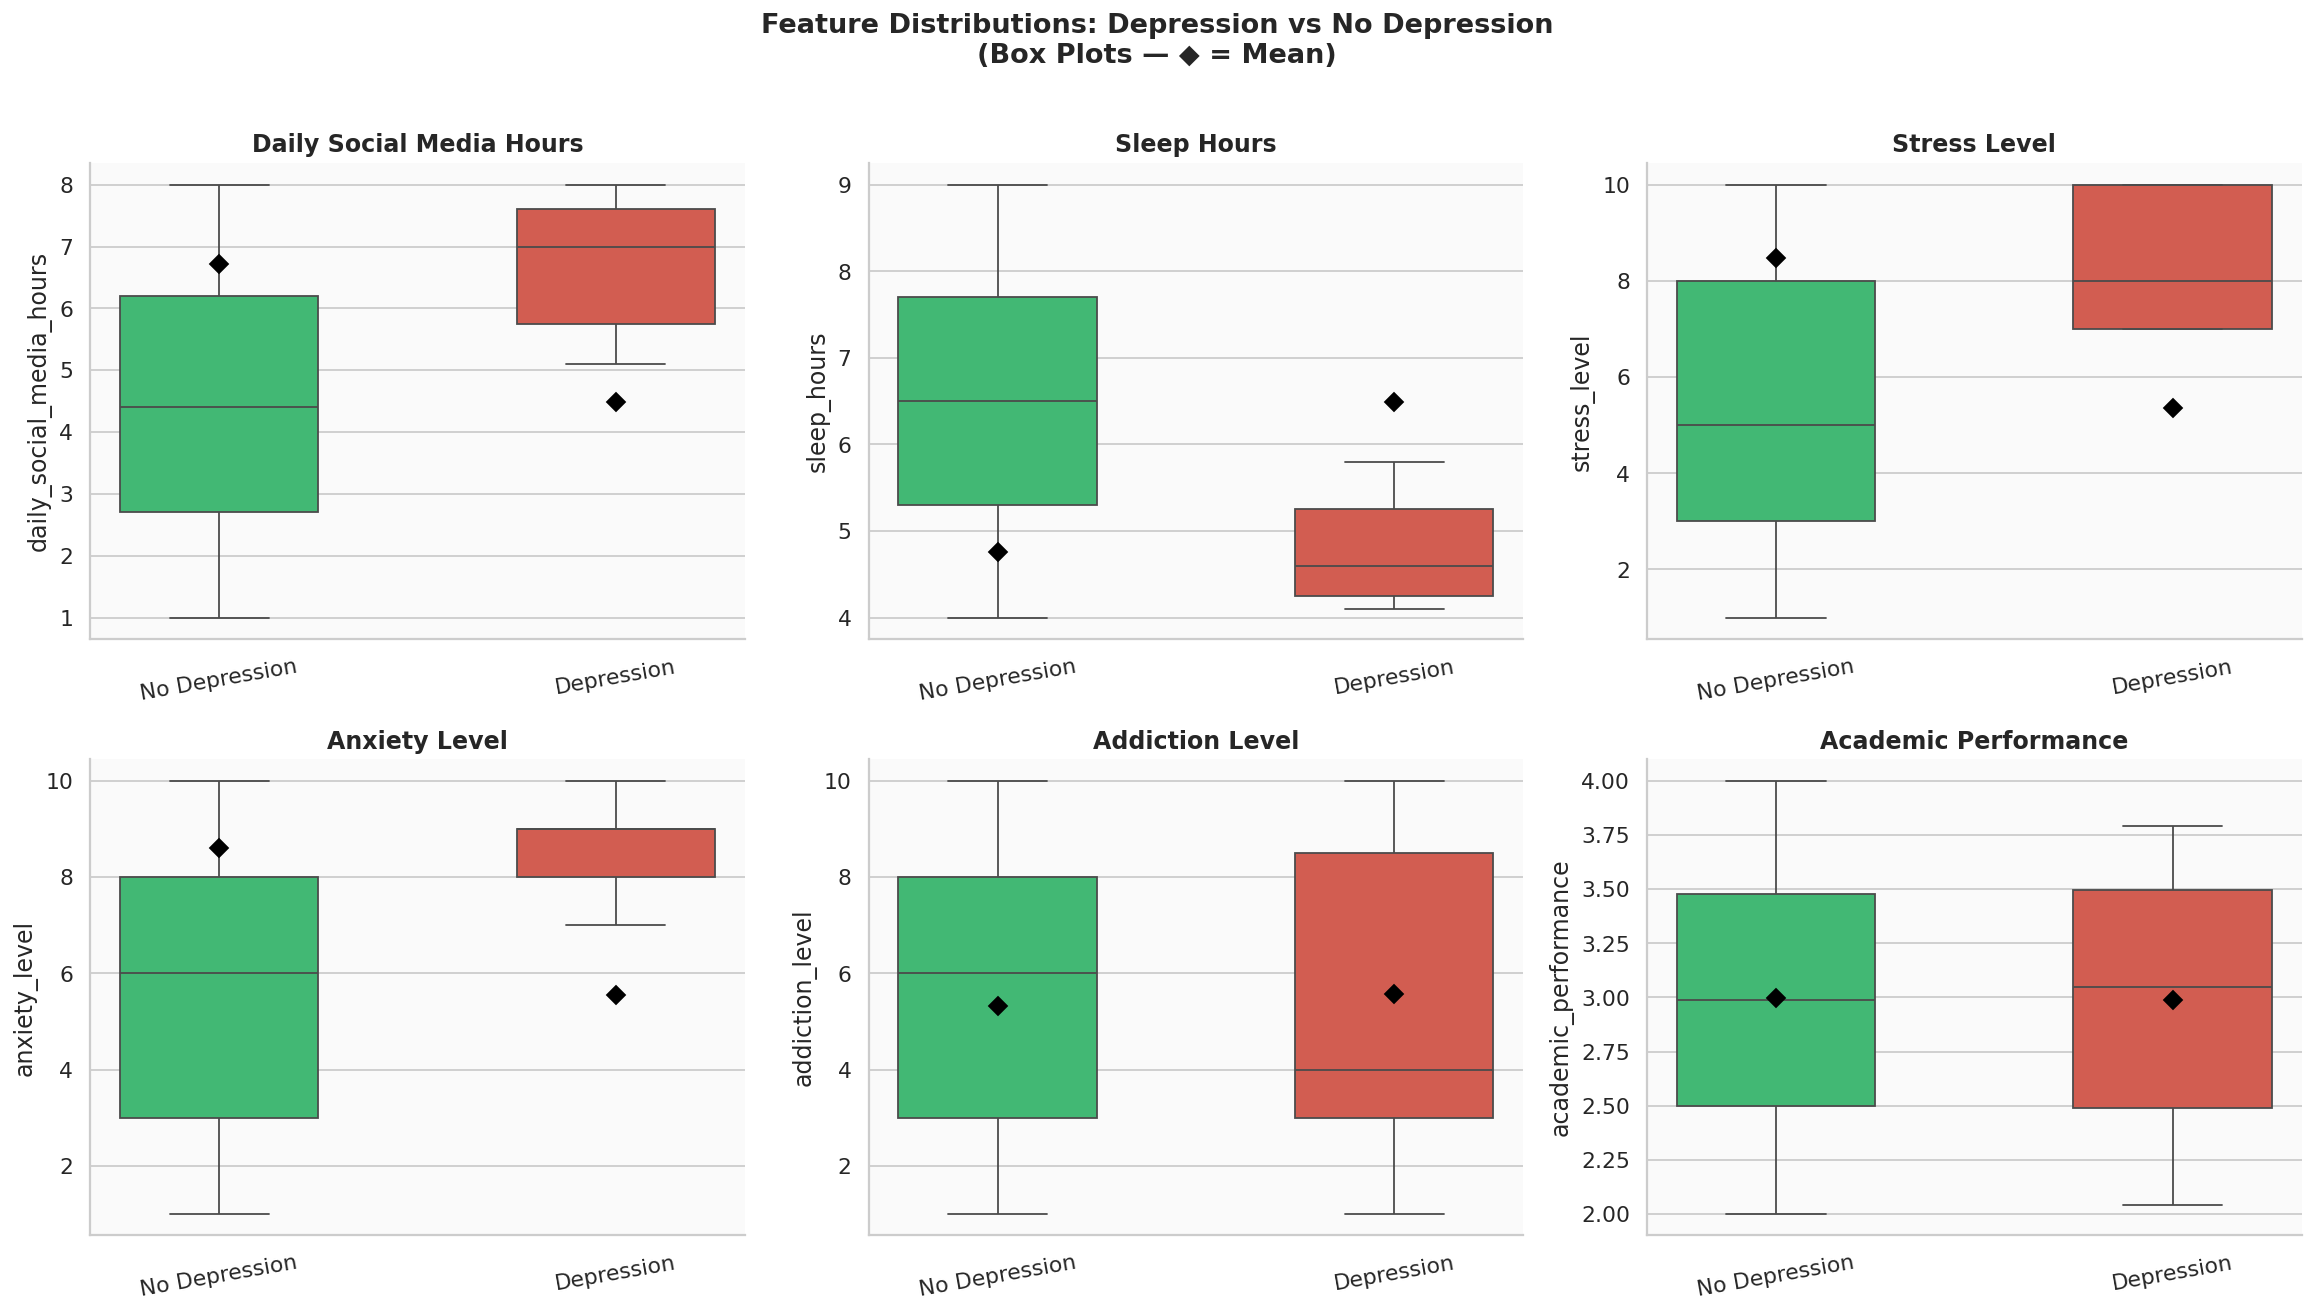

In [35]:
# ── Side-by-side box plots: Feature comparison by depression label ─────────────
compare_cols = ['daily_social_media_hours','sleep_hours','stress_level',
                'anxiety_level','addiction_level','academic_performance']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, compare_cols):
    sns.boxplot(data=df, x='depression_label_str', y=col,
                palette={'No Depression': '#2ecc71', 'Depression': '#e74c3c'},
                order=['No Depression', 'Depression'],
                ax=ax, width=0.5)
    # Add mean markers
    means = df.groupby('depression_label_str')[col].mean()
    for j, (label, mean) in enumerate(means.items()):
        ax.plot(j, mean, 'D', color='black', markersize=7, zorder=5)
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Feature Distributions: Depression vs No Depression\n(Box Plots — ◆ = Mean)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

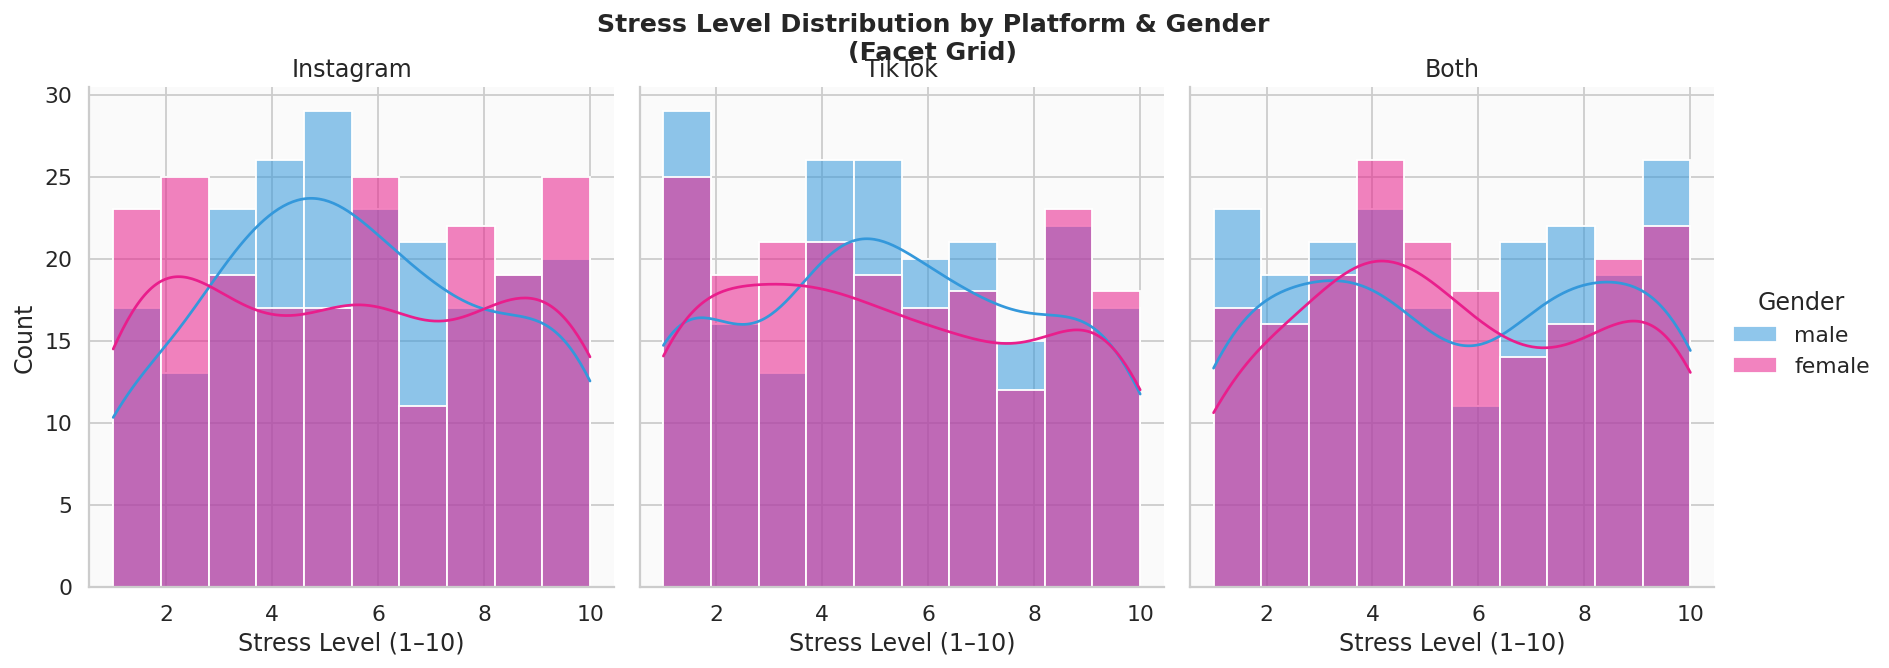

In [36]:
# ── FacetGrid: Stress level by platform × gender ──────────────────────────────
g = sns.FacetGrid(df, col='platform_usage', hue='gender',
                  palette=PAL_GENDER, height=5, aspect=0.9,
                  col_order=['Instagram', 'TikTok', 'Both'])
g.map(sns.histplot, 'stress_level', bins=10, alpha=0.55, kde=True)
g.add_legend(title='Gender')
g.set_axis_labels('Stress Level (1–10)', 'Count')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Stress Level Distribution by Platform & Gender\n(Facet Grid)',
                   fontsize=14, fontweight='bold', y=1.03)
plt.show()

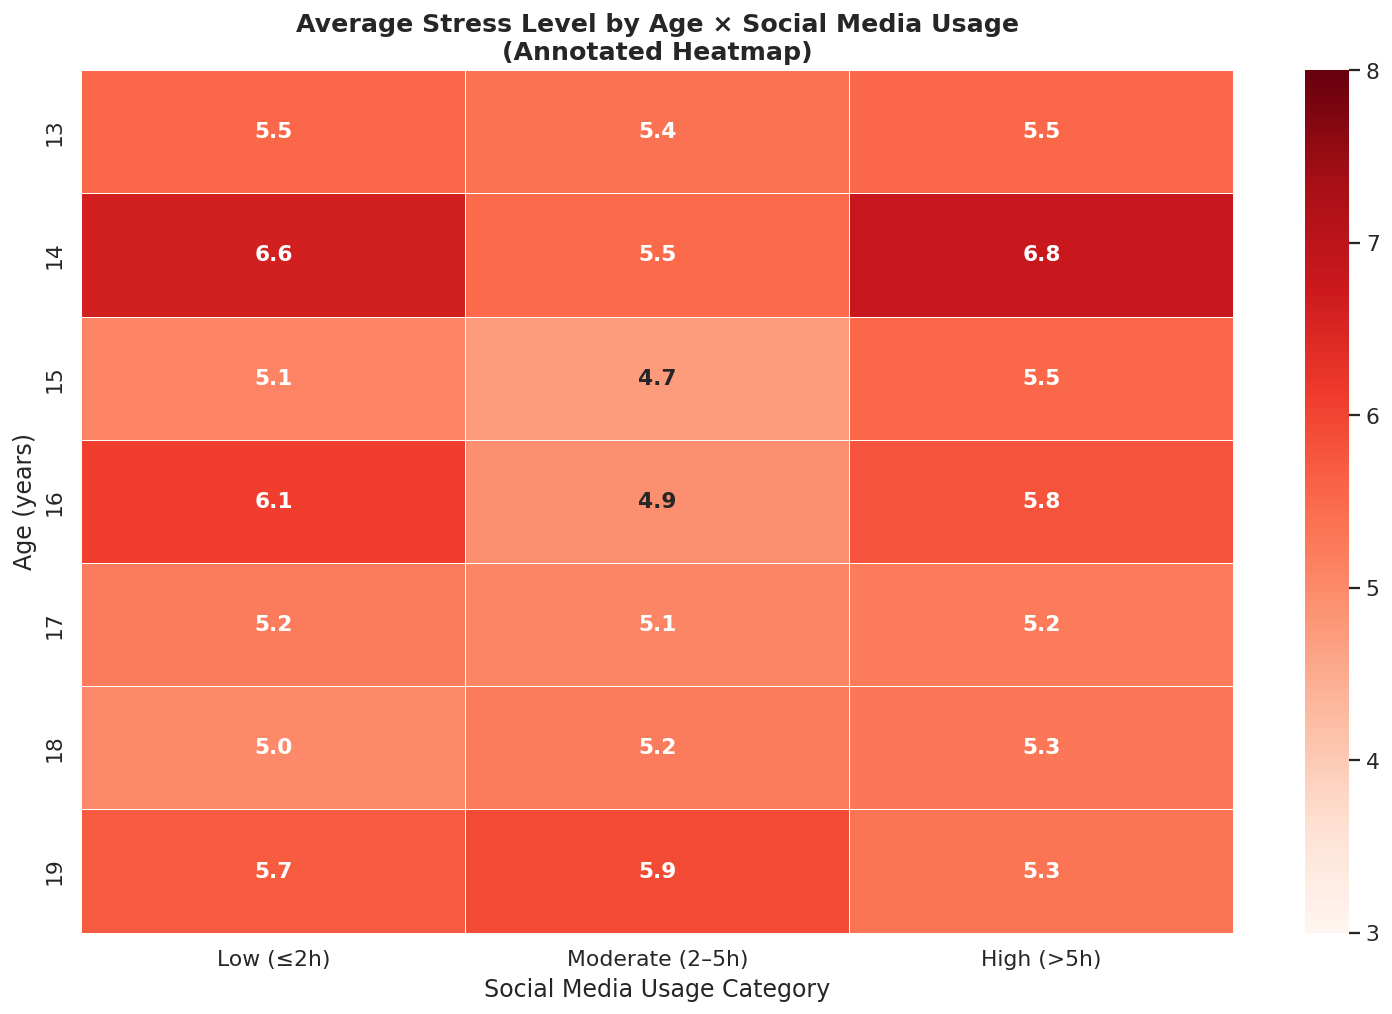

In [37]:
# ── Annotated heatmap: Avg stress by age × social media category ──────────────
pivot_stress = df.pivot_table(
    values='stress_level',
    index='age',
    columns='social_media_cat',
    aggfunc='mean',
    observed=True
)[['Low (≤2h)', 'Moderate (2–5h)', 'High (>5h)']]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_stress, annot=True, fmt='.1f', cmap='Reds',
            linewidths=0.5, ax=ax, vmin=3, vmax=8,
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Average Stress Level by Age × Social Media Usage\n(Annotated Heatmap)',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Social Media Usage Category')
ax.set_ylabel('Age (years)')
plt.tight_layout()
plt.show()

In [38]:
# ── Final summary statistics table ────────────────────────────────────────────
summary = pd.DataFrame({
    'Metric': [
        'Total Teens', 'Age Range', 'Avg Social Media/day',
        'Avg Sleep/night', 'Avg Stress (1-10)', 'Avg Anxiety (1-10)',
        'Avg Addiction (1-10)', 'Depression Rate',
        'Most Used Platform', 'Most Common Social Interaction'
    ],
    'Value': [
        f"{len(df):,}",
        f"{df['age'].min()}–{df['age'].max()} years",
        f"{df['daily_social_media_hours'].mean():.2f} hours",
        f"{df['sleep_hours'].mean():.2f} hours",
        f"{df['stress_level'].mean():.2f}",
        f"{df['anxiety_level'].mean():.2f}",
        f"{df['addiction_level'].mean():.2f}",
        f"{df['depression_label'].mean()*100:.1f}%",
        df['platform_usage'].mode()[0],
        df['social_interaction_level'].mode()[0]
    ]
})

print('='*50)
print('      TEEN MENTAL HEALTH — KEY FINDINGS')
print('='*50)
print(summary.to_string(index=False))
print('='*50)

      TEEN MENTAL HEALTH — KEY FINDINGS
                        Metric       Value
                   Total Teens       1,200
                     Age Range 13–19 years
          Avg Social Media/day  4.54 hours
               Avg Sleep/night  6.45 hours
             Avg Stress (1-10)        5.45
            Avg Anxiety (1-10)        5.64
          Avg Addiction (1-10)        5.57
               Depression Rate        2.6%
            Most Used Platform   Instagram
Most Common Social Interaction      medium


In [39]:
# ── Top correlations with mental health metrics ───────────────────────────────
print('\n📊 Top correlations with STRESS LEVEL:')
print(df[num_cols].corr()['stress_level'].drop('stress_level').sort_values(key=abs, ascending=False).head(5).to_string())

print('\n📊 Top correlations with DEPRESSION LABEL:')
print(df[num_cols].corr()['depression_label'].drop('depression_label').sort_values(key=abs, ascending=False).head(5).to_string())

print('\n📊 Top correlations with ANXIETY LEVEL:')
print(df[num_cols].corr()['anxiety_level'].drop('anxiety_level').sort_values(key=abs, ascending=False).head(5).to_string())


📊 Top correlations with STRESS LEVEL:
mental_health_score         0.585165
depression_label            0.170474
daily_social_media_hours    0.030698
anxiety_level               0.015811
physical_activity           0.012159

📊 Top correlations with DEPRESSION LABEL:
sleep_hours                -0.190630
mental_health_score         0.186638
daily_social_media_hours    0.175201
stress_level                0.170474
anxiety_level               0.169566

📊 Top correlations with ANXIETY LEVEL:
mental_health_score         0.594177
depression_label            0.169566
academic_performance       -0.064379
addiction_level             0.031154
daily_social_media_hours    0.027835
